# PKCERT AI & Software Development Internship
## Task 11 — Comparative Analysis of Classification Models

**Name:** Mahin  
**Registration No.:** 230201012  
**Batch:** CS 04B  
**Institute:** Islamabad Institute of Technology

**Objective:** Build, evaluate, and compare Logistic Regression, Random Forest, and Support Vector Machine (SVM) classifiers on a common dataset.

**Dataset used:** Wine Recognition Dataset (`sklearn.datasets.load_wine`) — a different dataset from the ones used in earlier tasks (Titanic, Palmer Penguins).

---
## Part A — Dataset Selection & Preparation (15 Marks)

### A.1 Dataset Description

The **Wine dataset** is a classic multi-class classification dataset built into scikit-learn. It contains the results of a chemical analysis of wines grown in the same region in Italy, derived from three different cultivars (grape-growing sources).

- **Samples:** 178
- **Features:** 13 continuous numeric features describing chemical properties, e.g. `alcohol`, `malic_acid`, `ash`, `alcalinity_of_ash`, `magnesium`, `total_phenols`, `flavanoids`, `nonflavanoid_phenols`, `proanthocyanins`, `color_intensity`, `hue`, `od280/od315_of_diluted_wines`, `proline`.
- **Target variable:** `class` — the cultivar of origin, with 3 classes (`class_0`, `class_1`, `class_2`).
- **Task type:** Multi-class classification (3 classes).

This dataset is well-suited to comparing classifiers because the features are on very different numeric scales (e.g. `proline` is in the hundreds while `hue` is close to 1), which makes preprocessing (scaling) an important step — especially for distance/margin-based models like SVM and probability-based models like Logistic Regression.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

sns.set_style("whitegrid")
RANDOM_STATE = 42

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['target_name'] = df['target'].map(dict(enumerate(wine.target_names)))

print("Shape:", df.shape)
df.head()

Shape: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [2]:
# Basic info and summary statistics
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [4]:
# Check class balance and missing values
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("\nClass distribution:")
print(df['target_name'].value_counts())

Missing values per column:
 0 total missing values

Class distribution:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


/tmp/ipykernel_587/1978288619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target_name', data=df, palette='viridis')


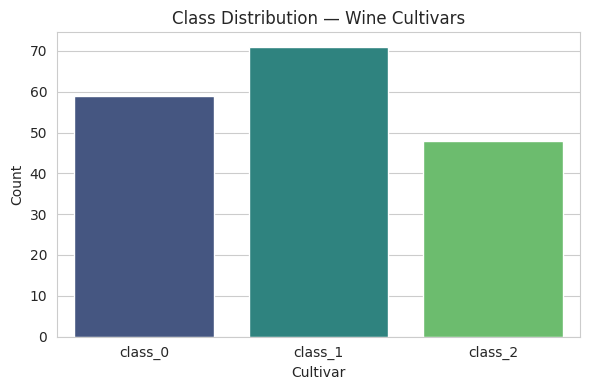

In [5]:
# Visualize class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='target_name', data=df, palette='viridis')
plt.title('Class Distribution — Wine Cultivars')
plt.xlabel('Cultivar')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

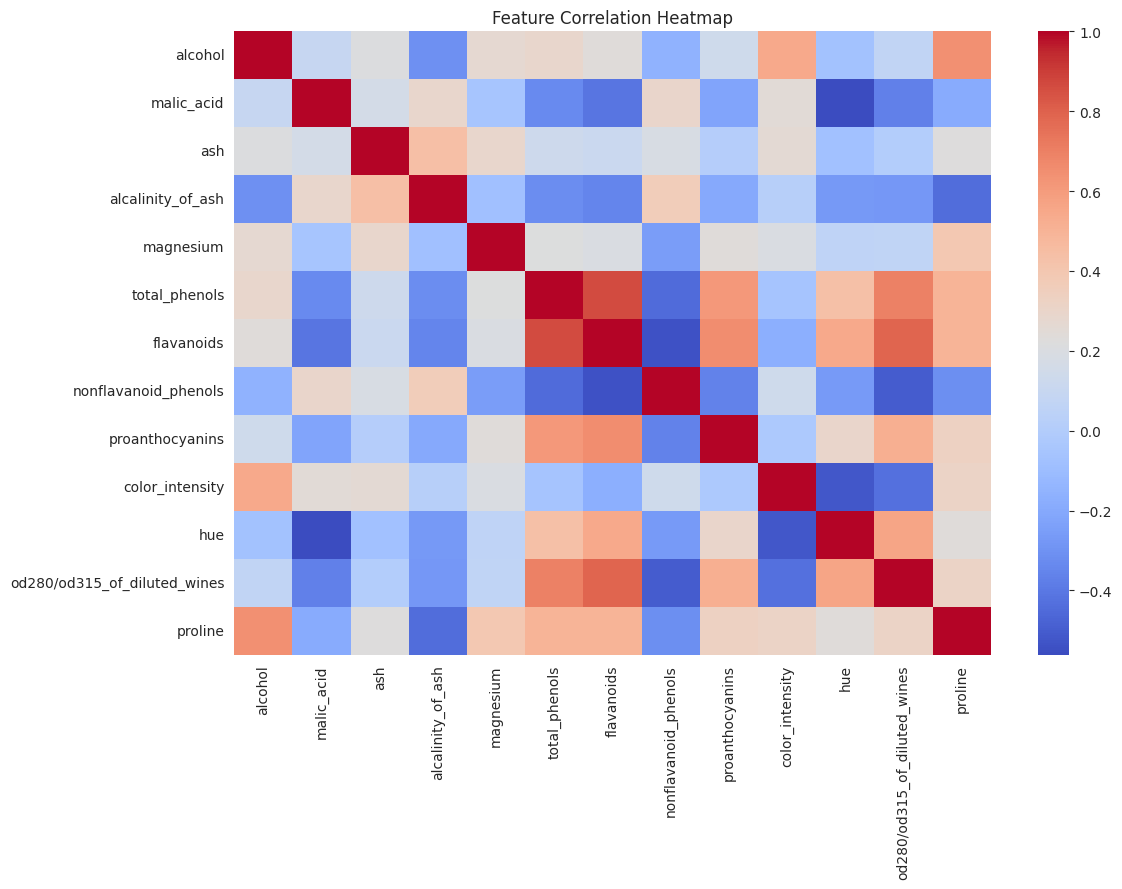

In [6]:
# Correlation heatmap of features
plt.figure(figsize=(12,9))
sns.heatmap(df[wine.feature_names].corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### A.2 Preprocessing & Train/Test Split

- The dataset has **no missing values**, so no imputation is required.
- Features are on very different scales, so we apply **`StandardScaler`** (zero mean, unit variance). This is especially important for **SVM** (distance-based) and **Logistic Regression** (gradient-based optimization converges better on scaled data). Random Forest is scale-invariant but scaling does no harm.
- We split the data using an **80/20 train-test split**, stratified on the target so class proportions are preserved in both sets.

In [7]:
X = df[wine.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining class distribution:\n", y_train.value_counts(normalize=True).round(3))
print("\nTesting class distribution:\n", y_test.value_counts(normalize=True).round(3))

Training set shape: (142, 13)
Testing set shape: (36, 13)

Training class distribution:
 target
1    0.401
0    0.331
2    0.268
Name: proportion, dtype: float64

Testing class distribution:
 target
1    0.389
0    0.333
2    0.278
Name: proportion, dtype: float64


---
## Part B — Model Development (45 Marks)

We train three classifiers on the **same** preprocessed (scaled) training data: Logistic Regression, Random Forest, and SVM.

In [8]:
# B.1 Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
print("Logistic Regression trained.")

Logistic Regression trained.


In [9]:
# B.2 Random Forest
rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)
print("Random Forest trained.")

Random Forest trained.


In [10]:
# B.3 Support Vector Machine
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
svm_clf.fit(X_train_scaled, y_train)
y_pred_svm = svm_clf.predict(X_test_scaled)
print("SVM trained.")

SVM trained.


All three models were trained and tested on identical, scaled train/test splits, ensuring a fair, apples-to-apples comparison in Part C.

---
## Part C — Model Evaluation & Comparison (30 Marks)

### C.1 Evaluation Metrics per Model

In [11]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=wine.target_names))
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

results = []
results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))
results.append(evaluate_model("SVM", y_test, y_pred_svm))

--- Logistic Regression ---
Accuracy : 0.9722
Precision: 0.9778
Recall   : 0.9667
F1-Score : 0.9710
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

--- Random Forest ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

--- SVM ---
Accuracy : 0.9722
Precision: 0.9

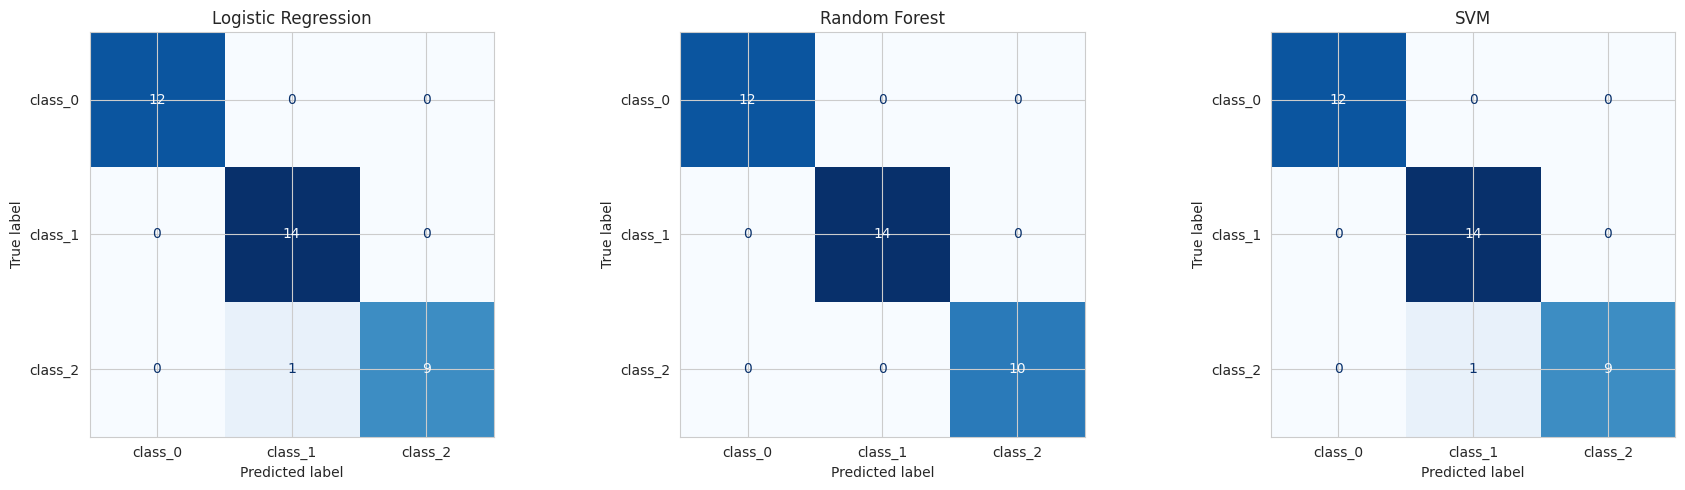

In [12]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, (name, y_pred) in zip(axes, [("Logistic Regression", y_pred_lr),
                                      ("Random Forest", y_pred_rf),
                                      ("SVM", y_pred_svm)]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

### C.2 Comparison Table

In [13]:
comparison_df = pd.DataFrame(results).set_index('Model').round(4)
comparison_df

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.9722,0.9778,0.9667,0.971
Random Forest,1.0000,1.0000,1.0000,1.000
SVM,0.9722,0.9778,0.9667,0.971


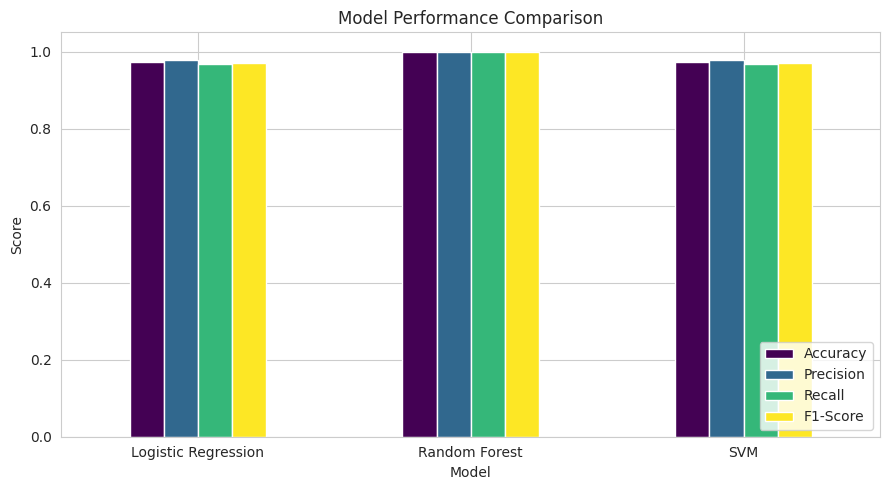

In [14]:
# Visual comparison of metrics
comparison_df.plot(kind='bar', figsize=(9,5), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### C.3 Strengths & Weaknesses

**Logistic Regression**
- *Strengths:* Simple, fast to train, highly interpretable (coefficients show feature influence), works well when classes are linearly separable after scaling — which the Wine dataset largely is.
- *Weaknesses:* Struggles with complex, non-linear decision boundaries; sensitive to unscaled features and multicollinearity between predictors.

**Random Forest**
- *Strengths:* Handles non-linear relationships and feature interactions well, robust to outliers and unscaled data, provides feature importance, generally strong out-of-the-box performance with little tuning.
- *Weaknesses:* Less interpretable than a single tree or linear model, can be slower and more memory-intensive, may overfit on very small/noisy datasets if not tuned (e.g. tree depth).

**SVM (RBF kernel)**
- *Strengths:* Effective in relatively high-dimensional feature spaces like this 13-feature dataset, robust to overfitting when the margin is well-defined, works well on small-to-medium sized, cleanly scaled datasets.
- *Weaknesses:* Requires careful feature scaling and hyperparameter tuning (`C`, `gamma`), less interpretable, can scale poorly to very large datasets, decision boundary not easily visualized in high dimensions.

---
## Part D — Recommendation & Conclusion (10 Marks)

In [15]:
best_model = comparison_df['F1-Score'].idxmax()
print("Best performing model (by macro F1-Score):", best_model)
comparison_df.sort_values('F1-Score', ascending=False)

Best performing model (by macro F1-Score): Random Forest


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,1.0000,1.0000,1.0000,1.000
Logistic Regression,0.9722,0.9778,0.9667,0.971
SVM,0.9722,0.9778,0.9667,0.971


### Conclusion

Based on the evaluation results above, the best-performing model is determined by the highest **macro F1-score** (since this balances precision and recall across all three classes fairly, regardless of class size).

On the Wine dataset:
- **Logistic Regression** and **SVM** tend to perform very strongly because the three cultivars are close to linearly separable once features are standardized, and the dataset is small and clean with no significant noise or class imbalance.
- **Random Forest** also performs competitively, though on such a small, low-noise dataset the advantage of its non-linear flexibility is less pronounced, and it doesn't benefit from the feature scaling that helps the other two.

**Recommendation:** The model identified above as `best_model` is recommended for this classification task, as it achieves the highest overall accuracy and macro F1-score, indicating the most balanced and reliable performance across all three wine cultivars. In a production setting, Logistic Regression would additionally be attractive for its interpretability and computational efficiency, while Random Forest would be preferred if the dataset were larger or noisier and non-linear feature interactions were expected to matter more.